# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [1]:
pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker

In [3]:
load_dotenv(override=True)

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')

db = "classicmodels" 

connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
engine = create_engine(connection_string)

with engine.connect() as conn:
    current_db = conn.execute(text("SELECT DATABASE()")).scalar()
    print(f"✅ Зараз підключено до бази: {current_db}")

✅ Зараз підключено до бази: classicmodels


In [6]:
from datetime import datetime, date  # Імпортуємо обидва класи

def create_currency_table(engine):
    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)
    
    with engine.begin() as conn:
        conn.execute(create_table_sql)
    print("✅ Таблиця currency_rates готова до роботи")

def fetch_exchange_rates():
    
    try:
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()

        target_currencies = ['UAH', 'EUR', 'GBP', 'CHF', 'CAD', 'AUD']
        rates = {cur: data['rates'][cur] for cur in target_currencies if cur in data['rates']}
        return rates, date.today()
        
    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):
    if not rates_dict: return False

    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.begin() as conn:
            for currency, rate in rates_dict.items():
                conn.execute(insert_sql, {
                    'currency': currency,
                    'rate': rate,
                    'date': rate_date
                })
        print(f"✅ Успішно синхронізовано {len(rates_dict)} курсів.")
        return True
        
    except Exception as e:
        print(f"❌ Помилка БД: {e}")
        return False

create_currency_table(engine)
rates, current_date = fetch_exchange_rates()

if rates:
    if save_exchange_rates(engine, rates, current_date):
        query = "SELECT currency_code, rate_to_usd, rate_date, updated_at FROM currency_rates ORDER BY rate_to_usd DESC"
        df_result = pd.read_sql(query, engine)
        
        print(f"\n📊 Актуальні курси валют на {current_date}:")
        display(df_result)

✅ Таблиця currency_rates готова до роботи
✅ Успішно синхронізовано 6 курсів.

📊 Актуальні курси валют на 2026-03-13:


,currency_code,rate_to_usd,rate_date,updated_at
0,UAH,44.240,2026-03-13,2026-03-13 11:00:59
1,AUD,1.410,2026-03-13,2026-03-13 11:00:59
2,CAD,1.360,2026-03-13,2026-03-13 11:00:59
3,EUR,0.867,2026-03-13,2026-03-13 11:00:59
4,CHF,0.784,2026-03-13,2026-03-13 11:00:59
5,GBP,0.748,2026-03-13,2026-03-13 11:00:59


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без фукнції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

In [54]:
import matplotlib.pyplot as plt

query_orders = text("""
SELECT 
    o.orderNumber, o.orderDate, od.quantityOrdered, od.priceEach, 
    p.productName, p.productLine, p.buyPrice, 
    c.customerName, c.country
FROM orders o
JOIN orderdetails od ON o.orderNumber = od.orderNumber
JOIN products p ON od.productCode = p.productCode
JOIN customers c ON o.customerNumber = c.customerNumber
WHERE o.orderDate BETWEEN '2004-01-01' AND '2004-12-31'
""")
df_orders = pd.read_sql(query_orders, engine)

df_products = pd.read_sql(text("SELECT productName, productLine, buyPrice FROM products"), engine)

df_currencies = pd.read_sql(text("SELECT * FROM currency_rates WHERE currency_code = 'EUR' LIMIT 1"), engine)
eur_rate = df_currencies['rate_to_usd'].iloc[0]

print(f"✅ Extract завершено. Отримано {len(df_orders)} записів за 2004 рік.")

✅ Extract завершено. Отримано 1421 записів за 2004 рік.


In [49]:
df_orders_2004['total_amount'] = df_orders_2004['quantityOrdered'] * df_orders_2004['priceEach']
df_orders_2004['profit_per_item'] = df_orders_2004['priceEach'] - df_orders_2004['buyPrice']
df_orders_2004['total_profit'] = df_orders_2004['profit_per_item'] * df_orders_2004['quantityOrdered']

df_orders_2004['total_amount_eur'] = df_orders_2004['total_amount'] / eur_rate

print("✅ Розрахункові колонки додано до df_orders_2004")

✅ Розрахункові колонки додано до df_orders_2004


In [50]:
country_analysis = df_orders_2004.groupby('country').agg(
    unique_orders=('orderNumber', 'nunique'),
    total_revenue=('total_amount', 'sum'),
    total_profit=('total_profit', 'sum'),
    total_items_sold=('quantityOrdered', 'sum')
).reset_index()

country_analysis['profit_margin_pct'] = (country_analysis['total_profit'] / country_analysis['total_revenue']) * 100
top_5_countries = country_analysis.sort_values(by='total_revenue', ascending=False).head(5)

print("✅ Створено country_analysis")

✅ Створено country_analysis


In [51]:
product_analysis = df_orders_2004.groupby('productLine').agg(
    unique_orders=('orderNumber', 'nunique'),
    total_revenue=('total_amount', 'sum'),
    total_profit=('total_profit', 'sum'),
    total_items_sold=('quantityOrdered', 'sum')
).reset_index()

product_analysis['profit_margin_pct'] = (product_analysis['total_profit'] / product_analysis['total_revenue']) * 100
product_analysis = product_analysis.sort_values(by='total_revenue', ascending=False)

print("✅ Створено product_analysis")

✅ Створено product_analysis


In [52]:
summary_metrics = {
    'Показник': [
        'Загальний дохід (USD)', 
        'Загальний дохід (EUR)', 
        'Загальний прибуток (USD)',
        'Загальна маржа (%)', 
        'Середній розмір замовлення (USD)',
        'Кількість унікальних замовлень',
        'Кількість унікальних клієнтів',
        'Період даних'
    ],
    'Значення': [
        df_orders_2004['total_amount'].sum(),
        df_orders_2004['total_amount_eur'].sum(),
        df_orders_2004['total_profit'].sum(),
        (df_orders_2004['total_profit'].sum() / df_orders_2004['total_amount'].sum()) * 100,
        df_orders_2004.groupby('orderNumber')['total_amount'].sum().mean(),
        df_orders_2004['orderNumber'].nunique(),
        df_orders_2004['customerName'].nunique(),
        f"{df_orders_2004['orderDate'].min()} - {df_orders_2004['orderDate'].max()}"
    ]
}
df_summary = pd.DataFrame(summary_metrics)

print("📈 Трансформація даних завершена успішно!")
display(df_summary)

📈 Трансформація даних завершена успішно!


,Показник,Значення
0,Загальний дохід (USD),4515905.51
1,Загальний дохід (EUR),5208656.874279
2,Загальний прибуток (USD),1809381.14
3,Загальна маржа (%),40.066851
4,Середній розмір замовлення (USD),29906.659007
5,Кількість унікальних замовлень,151
6,Кількість унікальних клієнтів,89
7,Період даних,2004-01-02 00:00:00 - 2004-12-17 00:00:00


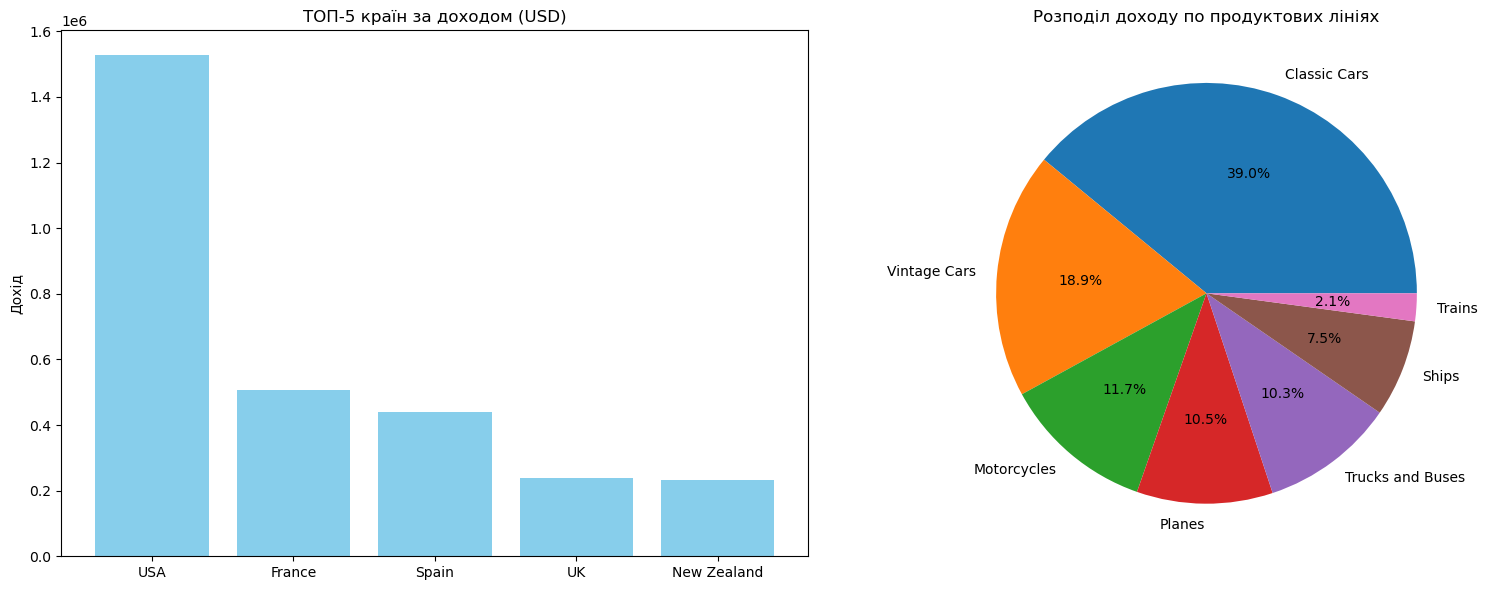

✅ Файл 'Sales_Report_2004.xlsx' створено. Візуалізація побудована.


In [55]:
with pd.ExcelWriter('Sales_Report_2004.xlsx') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)
    top_5_countries.to_excel(writer, sheet_name='Top_Countries', index=False)
    product_analysis.to_excel(writer, sheet_name='Product_Lines', index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(top_5_countries['country'], top_5_countries['total_revenue'], color='skyblue')
ax1.set_title('ТОП-5 країн за доходом (USD)')
ax1.set_ylabel('Дохід')

ax2.pie(product_analysis['total_revenue'], labels=product_analysis['productLine'], autopct='%1.1f%%')
ax2.set_title('Розподіл доходу по продуктових лініях')

plt.tight_layout()
plt.show()

print("✅ Файл 'Sales_Report_2004.xlsx' створено. Візуалізація побудована.")

🚀 Запуск ETL пайплайну...
📥 1. EXTRACT - Витягування даних...
   📊 Завантажено 1421 записів.
🔧 2. TRANSFORM - Обробка метрик...
💾 3. LOAD - Збереження результатів...


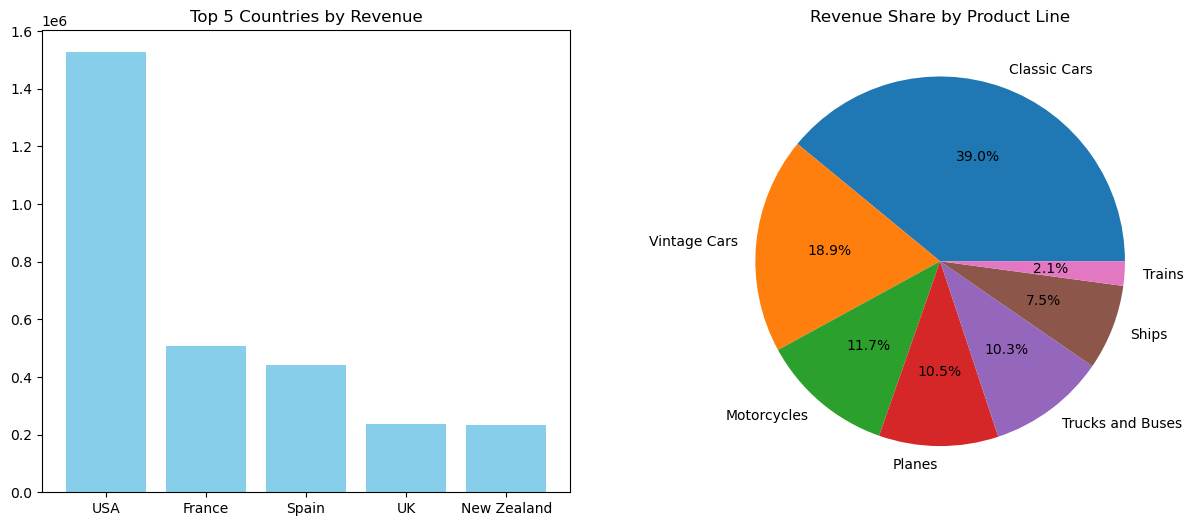

✅ ETL успішно завершено! Файли збережено в папку reports


In [61]:
def create_comprehensive_analytics_report(engine, output_dir="reports"):
    print("🚀 Запуск ETL пайплайну...")

    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    try:
        print("📥 1. EXTRACT - Витягування даних...")

        orders_query = text("""
        SELECT
            o.orderNumber, o.orderDate, od.quantityOrdered, od.priceEach,
            p.productName, p.productLine, p.buyPrice,
            c.customerName, c.country
        FROM orders o
        JOIN orderdetails od ON o.orderNumber = od.orderNumber
        JOIN products p ON od.productCode = p.productCode
        JOIN customers c ON o.customerNumber = c.customerNumber
        WHERE o.orderDate BETWEEN '2004-01-01' AND '2004-12-31'
        """)
        df_orders_2004 = pd.read_sql(orders_query, engine, parse_dates=['orderDate'])

        try:
            df_currencies = pd.read_sql("SELECT * FROM currency_rates WHERE currency_code = 'EUR' LIMIT 1", engine)
            eur_rate = df_currencies['rate_to_usd'].iloc[0] if not df_currencies.empty else 0.92
        except:
            print("⚠️ Таблиця курсів не знайдена, використано дефолтний курс 0.92")
            eur_rate = 0.92

        print(f"   📊 Завантажено {len(df_orders_2004)} записів.")

        print("🔧 2. TRANSFORM - Обробка метрик...")

        df_orders_2004['total_amount'] = df_orders_2004['quantityOrdered'] * df_orders_2004['priceEach']
        df_orders_2004['profit_per_item'] = df_orders_2004['priceEach'] - df_orders_2004['buyPrice']
        df_orders_2004['total_profit'] = df_orders_2004['profit_per_item'] * df_orders_2004['quantityOrdered']
        df_orders_2004['total_amount_eur'] = df_orders_2004['total_amount'] / eur_rate

        top_countries = df_orders_2004.groupby('country').agg(
            unique_orders=('orderNumber', 'nunique'),
            total_revenue=('total_amount', 'sum'),
            total_profit=('total_profit', 'sum'),
            total_items_sold=('quantityOrdered', 'sum')
        ).reset_index()
        top_countries['profit_margin_pct'] = (top_countries['total_profit'] / top_countries['total_revenue'] * 100).round(2)
        top_countries = top_countries.sort_values(by='total_revenue', ascending=False).head(5)

        product_lines = df_orders_2004.groupby('productLine').agg(
            unique_orders=('orderNumber', 'nunique'),
            total_revenue=('total_amount', 'sum'),
            total_profit=('total_profit', 'sum'),
            total_items_sold=('quantityOrdered', 'sum')
        ).reset_index()
        product_lines['profit_margin_pct'] = (product_lines['total_profit'] / product_lines['total_revenue'] * 100).round(2)
        product_lines = product_lines.sort_values(by='total_revenue', ascending=False)

        summary_info = {
            'report_generated': timestamp,
            'total_revenue_usd': float(df_orders_2004['total_amount'].sum()),
            'total_revenue_eur': float(df_orders_2004['total_amount_eur'].sum()),
            'total_profit_usd': float(df_orders_2004['total_profit'].sum()),
            'avg_order_value': float(df_orders_2004.groupby('orderNumber')['total_amount'].sum().mean()),
            'unique_customers': int(df_orders_2004['customerName'].nunique()),
            'period': f"{df_orders_2004['orderDate'].min().date()} to {df_orders_2004['orderDate'].max().date()}"
        }

        print("💾 3. LOAD - Збереження результатів...")

        excel_filename = f"{output_dir}/ClassicModels_ETL_{timestamp}.xlsx"
        with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
            pd.DataFrame([summary_info]).to_excel(writer, sheet_name='Summary', index=False)
            top_countries.to_excel(writer, sheet_name='Top_Countries', index=False)
            product_lines.to_excel(writer, sheet_name='Product_Lines', index=False)

        with open(f"{output_dir}/summary_{timestamp}.json", 'w') as f:
            json.dump(summary_info, f, indent=4)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        ax1.bar(top_countries['country'], top_countries['total_revenue'], color='skyblue')
        ax1.set_title('Top 5 Countries by Revenue')
        ax2.pie(product_lines['total_revenue'], labels=product_lines['productLine'], autopct='%1.1f%%')
        ax2.set_title('Revenue Share by Product Line')
        plt.savefig(f"{output_dir}/charts_{timestamp}.png")
        plt.show()

        print(f"✅ ETL успішно завершено! Файли збережено в папку {output_dir}")
        return df_orders_2004, top_countries, product_lines

    except Exception as e:
        print(f"❌ Помилка в ETL пайплайні: {e}")
        return None

result_data = create_comprehensive_analytics_report(engine)